# Common Random Number GP

This notebook walks through an example of a ''common random number'' (crn) GP. The crnGP is described in detail in (Fadkihar et. al 2022)[https://ieeexplore.ieee.org/abstract/document/10408258]. 

The main idea behind the crnGP is that we can utilize random seed information to assess the correlation between different random seeds. This makes it possible to do trajectory-level inference for the location and random seed pairing (x,r).

In the following example, we design a synthetic function that is evaluated as:
$$
Y(x,s) = \sin(x + \frac{\pi}{2}\mathcal{1}(s==5)) + s
$$

Which evaluates the sine function and shifts the amplitude by the value of the random seed $s$, and also introduces a phase shift if the random seed is equal to 5.

We evaluate the function over $x \in [0,2\pi]$ and for seeds $s \in {1,5}$

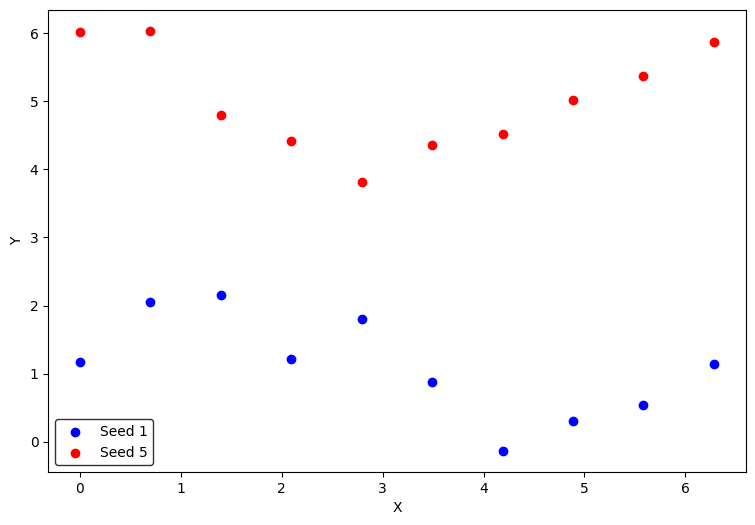

In [11]:
from hetgpy import crnGP
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

pps = 10 # points per seed
x = np.linspace(0,2*np.pi,pps).reshape(-1,1)
X = np.vstack([x,x])
seeds = ([1] * pps) + ([5] * pps)
X = np.hstack([X,np.array(seeds).reshape(-1,1)])
# amplitude and phase shift
Z = np.sin(X[:,0] + (np.pi/2)*(X[:,-1]==5)) + X[:,-1]
Ztrue = Z.copy()
noise = 0.5 * rng.normal(size = Z.size)
Z += noise
fig, ax = plt.subplots(figsize=(9,6))

m1 = X[:,-1]==1
m2 = X[:,-1]==5
ax.scatter(X[m1][:,0],Z[m1],color='blue',label='Seed 1')
ax.scatter(X[m2][:,0],Z[m2],color='red',label='Seed 5')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(edgecolor='black');

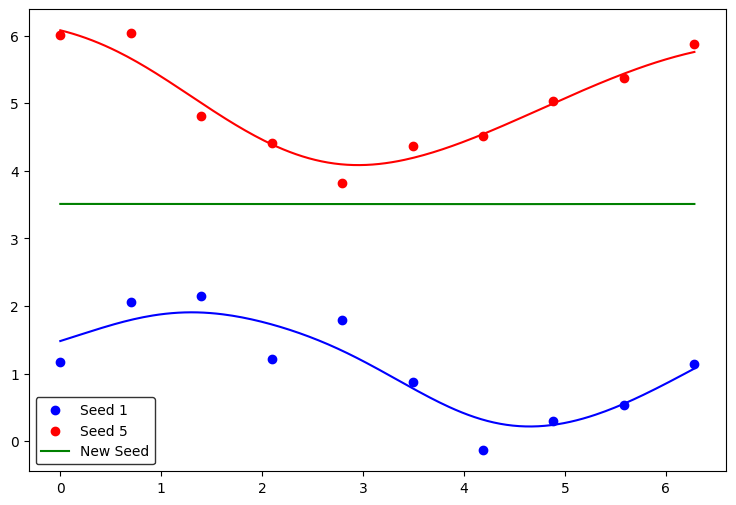

In [13]:
from hetgpy.optim import crit_EI
model = crnGP()
with np.errstate(divide='ignore', invalid='ignore'):
    model.mle(X,Z,covtype="Matern5_2")
pp = 200
xp = np.linspace(0,2*np.pi,pp).reshape(-1,1)
Xp = np.vstack([xp,xp])
seeds = ([1] * pp) + ([5] * pp)
Xp = np.hstack([Xp,np.array(seeds).reshape(-1,1)])

with np.errstate(divide='ignore', invalid='ignore'):
    preds = model.predict(Xp,xprime=Xp)

fig, ax = plt.subplots(figsize=(9,6))

# data
m1 = X[:,-1]==1
m2 = X[:,-1]==5
ax.scatter(X[m1][:,0],Z[m1],color='blue',label='Seed 1')
ax.scatter(X[m2][:,0],Z[m2],color='red',label='Seed 5')


# preds

ax.plot(xp,preds['mean'][0:pp],color='blue')
ax.plot(xp,preds['mean'][pp:],color='red')

Xns = Xp[0:pp,:].copy()
Xns[:,-1] = 10
with np.errstate(divide='ignore', invalid='ignore'):
    preds_new_seed = model.predict(Xns,xprime=Xns)
ax.plot(xp,preds_new_seed['mean'],color='green',label = 'New Seed')



ax.legend(edgecolor='black');